# Basketball Training Notebook

In [58]:
%load_ext autoreload
%autoreload 2

import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
# from torchvision.models.detection.faster_rcnn import FastRCNNPredictor, FasterRCNN
# from torchvision.transforms.v2 import functional as F
# from torchvision.transforms import v2
# from torchvision import tv_tensors
# import torch.utils.data
# from torch.utils.data import DataLoader, Dataset
# import torchvision.transforms as T
# import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# import xml.etree.ElementTree as ET
import os
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from PIL import Image
# from tqdm import tqdm
# import glob
# import ssl
from collections import Counter
import pandas as pd

from src.utils import BasketballDataset, parse_voc_xml, visualize_sample, get_transforms
from src.models import detection_collate_fn, make_detection_loader, EarlyStopping, ModifiedFasterRCNN

# # Fix SSL certificate verification issue
# ssl._create_default_https_context = ssl._create_unverified_context

# Check for GPU availability
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(torchmetrics.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda
PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
1.9.0


# Define Class Labels

ID 	Class Name 	Default Confidence
0 	Ball 	0.60
1 	Ball in Basket 	0.25
2 	Player 	0.70
3 	Basket 	0.70
4 	Player Shooting 	0.77

In [2]:
# mapping of XML strings to class indices
# Original mapping was for YOLO, which doesn't reserve 0 for background. Faster RCNN does, so we shift everything up as we convert to int

CLASS_MAPPING = {
    '0': 1,
    '1': 2,
    '2': 3,
    '3': 4,
    '4': 5
}


# Class mapping for road signs
# 0 is reserved for background
CLASS_NAMES_TO_INDEX = {
    'background': 0,
    'ball': 1,
    'ball_in_basket': 2,
    'player': 3,
    'basket': 4,
    'player_shooting': 5
}



# Reverse mapping for visualization
IDX_TO_CLASS = {v: k for k, v in CLASS_NAMES_TO_INDEX.items()}



# Define colors for different classes
CLASS_COLORS = {
     'ball': 'red',
    'ball_in_basket': 'gray',
    'player': 'blue',
    'basket': 'green',
    'player_shooting': 'orange'
}

NUM_CLASSES = len(CLASS_NAMES_TO_INDEX)  # Including background

print(f"Number of classes (including background): {NUM_CLASSES}")
print(f"Class mapping: {CLASS_NAMES_TO_INDEX}")

Number of classes (including background): 6
Class mapping: {'background': 0, 'ball': 1, 'ball_in_basket': 2, 'player': 3, 'basket': 4, 'player_shooting': 5}


# Loading in Dataset

In [3]:
data_dir = 'roboflow_basketball_detection_data'

In [4]:
parse_voc_xml('roboflow_basketball_detection_data/test/2-2_1_16_jpg.rf.8bd32770be28990a3c9e7d83bf690e97.xml', CLASS_MAPPING)

([[256, 365, 312, 504],
  [320, 368, 371, 490],
  [279, 379, 313, 499],
  [297, 357, 309, 377],
  [308, 271, 328, 306]],
 [3, 3, 3, 1, 4])

## Define transforms

In [5]:
train_transforms = get_transforms(is_train=True)

In [6]:
test_transforms = get_transforms(is_train=False)

In [7]:
# Construct training dataset
train_path = f'{data_dir}/train'

if os.path.exists(train_path):
    train_dataset = BasketballDataset(train_path, CLASS_MAPPING, train_transforms)
    print(f"Dataset size: {len(train_dataset)} images")


Dataset size: 9599 images


In [8]:

# Test loading one sample
img, target = train_dataset[0]
print(f"\nSample data:")
print(f"Image shape: {img.shape}")
print(f"Number of objects: {len(target['boxes'])}")
print(f"Boxes shape: {target['boxes'].shape}")
print(f"Labels: {target['labels'].tolist()}")
print(f"Class names: {[IDX_TO_CLASS[l.item()] for l in target['labels']]}")


Sample data:
Image shape: torch.Size([3, 640, 640])
Number of objects: 6
Boxes shape: torch.Size([6, 4])
Labels: [4, 1, 3, 3, 3, 5]
Class names: ['basket', 'ball', 'player', 'player', 'player', 'player_shooting']


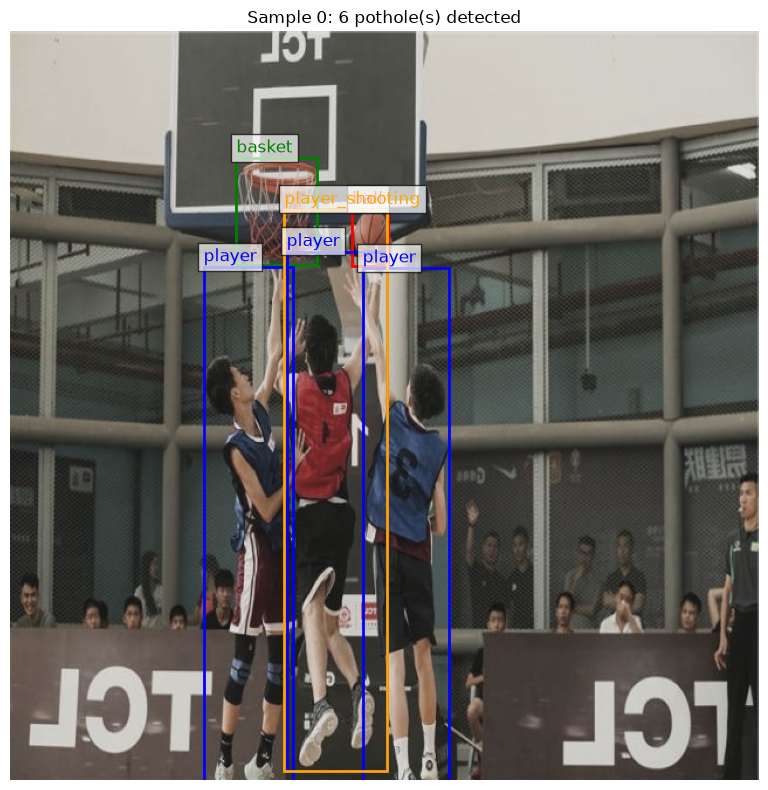

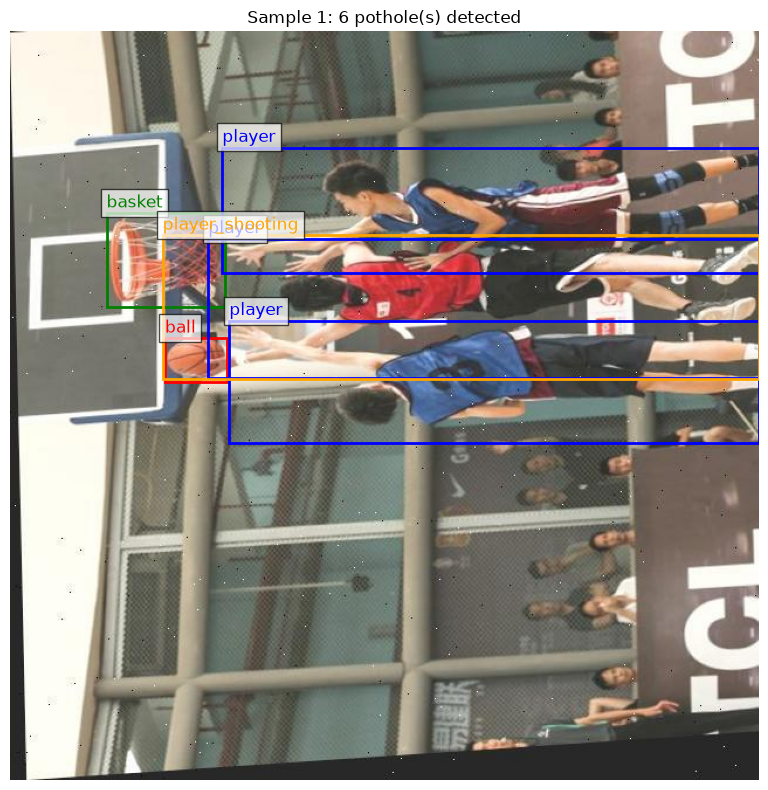

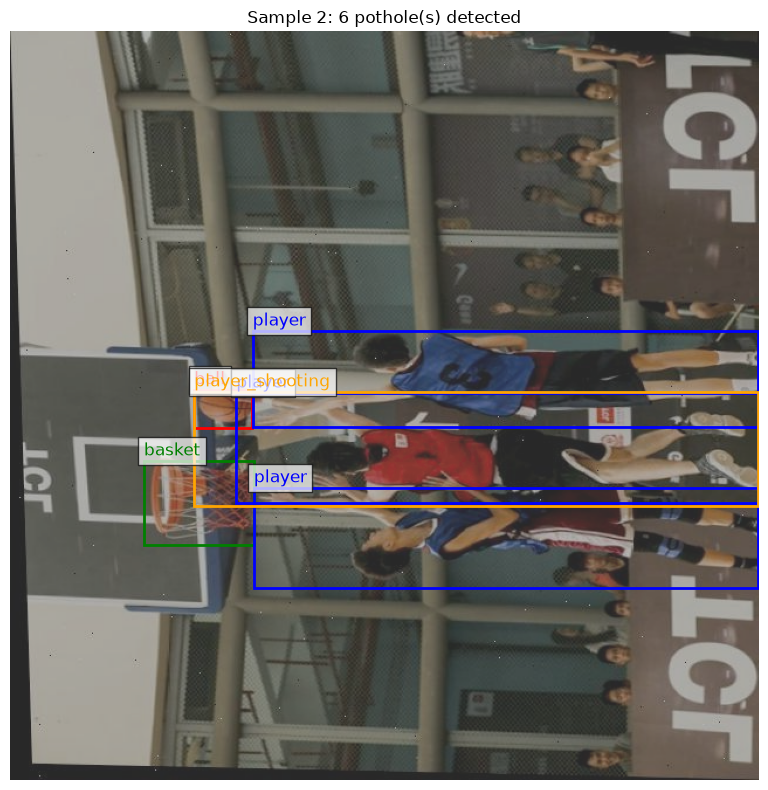

In [9]:

for i in range(min(3, len(train_dataset))):
    visualize_sample(train_dataset, i, IDX_TO_CLASS, CLASS_COLORS)

# Discussion

* So it looks like the data already comes with some augmentation in the form of duplication and rotation. That's good news, maybe.
* I don't love the 90 degree rotations, honestly. Gravity matters here, and the ball being above the rim matters.
* Data quality seems reasonable otherwise, bounding boxes are good.

# Create Datasets

* We already have the train dataset defined from earlier. So we just need to define the validation and test sets. Each of those have their own directories

In [10]:
valid_path = f'{data_dir}/valid'

if os.path.exists(valid_path):
    valid_dataset = BasketballDataset(valid_path, CLASS_MAPPING, test_transforms)
    print(f"Dataset size: {len(valid_dataset)} images")


Dataset size: 873 images


In [11]:

test_path = f'{data_dir}/test'

if os.path.exists(test_path):
    test_dataset = BasketballDataset(test_path, CLASS_MAPPING, test_transforms)
    print(f"Dataset size: {len(test_dataset)} images")


Dataset size: 436 images


# Some quick label EDA

In [59]:
def class_distribution(dataset, class_names=None):
    """Count label occurrences across a detection dataset.

    Returns a dict with per-class instance counts (total boxes) and image
    counts (images containing >=1 of that class). Iterates the dataset's
    targets without running the model.

    class_names: optional {index: name} to label the output; if given, keys
    are names, else integer indices.
    """
    instance_counts = Counter()   # total boxes per class
    image_counts = Counter()      # images containing >=1 box of the class

    for i in range(len(dataset)):
        _, target = dataset[i]                 # (image, target) pair
        labels = target['labels']
        # labels is a tensor of per-box class indices for this image
        labels_list = labels.tolist() if torch.is_tensor(labels) else list(labels)

        # instance count: every box
        for lab in labels_list:
            instance_counts[int(lab)] += 1
        # image count: each class present at most once per image
        for lab in set(labels_list):
            image_counts[int(lab)] += 1

    # assemble, optionally mapping indices -> names
    def key(idx):
        return class_names[idx] if class_names else idx

    all_classes = sorted(set(instance_counts) | set(image_counts))
    result = {}
    for idx in all_classes:
        result[key(idx)] = {
            'instances': instance_counts[idx],
            'images': image_counts[idx],
        }
    return result

In [60]:
CLASS_NAMES = {1:'ball', 2:'ball_in_basket', 3:'player', 4:'basket', 5:'player_shooting'}
dist = class_distribution(train_dataset, CLASS_NAMES)
for name, counts in dist.items():
    print(f"{name:16s} instances={counts['instances']:6d}  images={counts['images']:6d}")

ball             instances=  9485  images=  8261
ball_in_basket   instances=   972  images=   966
player           instances= 18392  images=  5985
basket           instances=  6490  images=  6333
player_shooting  instances=  1864  images=  1857


# Create DataLoaders

In [12]:
train_loader = make_detection_loader(train_dataset, batch_size=4, shuffle=True)
val_loader   = make_detection_loader(valid_dataset,   batch_size=4, shuffle=False)
test_loader  = make_detection_loader(test_dataset,  batch_size=4, shuffle=False)

# Experiment 1

In [13]:
device

device(type='cuda')

In [14]:
DETECTION_MODEL = fasterrcnn_resnet50_fpn(weights='DEFAULT', trainable_backbone_layers=3)
OPTIMIZER = torch.optim.SGD
SCHEDULER = ReduceLROnPlateau
EARLY_STOPPER = EarlyStopping
EARLY_STOPPER_KWARGS={'patience':10}

In [15]:
experiment_1 = ModifiedFasterRCNN(
    detection_model=DETECTION_MODEL,
    optimizer=OPTIMIZER,
    learning_scheduler=SCHEDULER,
    early_stopper_class=EARLY_STOPPER,
    early_stopper_kwargs=EARLY_STOPPER_KWARGS)

In [16]:
experiment_1.replace_box_predictor(num_classes=NUM_CLASSES)

In [17]:
experiment_1.training_loop(train_loader=train_loader,
                           val_loader=val_loader,
                           device=device,
                           epochs=200,
                           optimizer__lr=0.005,
                           optimizer__momentum=0.9,
                           optimizer__weight_decay=0.0005,
                           scheduler__mode='min',
                           scheduler__patience=3,
                           calculate_map_interval=5,
                           print_every=200)

Starting detection training for 200 epoch(s)
  trainable params: 41,097,261 | train batches/epoch: 2400 | device: cuda

Epoch 1/200
  Epoch 1/200 batch 200/2400 | loss 0.4996 | loss_classifier=0.150 loss_box_reg=0.214 loss_objectness=0.033 loss_rpn_box_reg=0.059
  Epoch 1/200 batch 400/2400 | loss 0.4513 | loss_classifier=0.215 loss_box_reg=0.294 loss_objectness=0.055 loss_rpn_box_reg=0.043
  Epoch 1/200 batch 600/2400 | loss 0.4250 | loss_classifier=0.085 loss_box_reg=0.113 loss_objectness=0.018 loss_rpn_box_reg=0.005
  Epoch 1/200 batch 800/2400 | loss 0.4051 | loss_classifier=0.101 loss_box_reg=0.177 loss_objectness=0.008 loss_rpn_box_reg=0.034
  Epoch 1/200 batch 1000/2400 | loss 0.3905 | loss_classifier=0.074 loss_box_reg=0.192 loss_objectness=0.011 loss_rpn_box_reg=0.020
  Epoch 1/200 batch 1200/2400 | loss 0.3820 | loss_classifier=0.100 loss_box_reg=0.150 loss_objectness=0.008 loss_rpn_box_reg=0.007
  Epoch 1/200 batch 1400/2400 | loss 0.3721 | loss_classifier=0.066 loss_box_reg

In [18]:
torch.save(experiment_1.model.state_dict(), 'basketball_current.pt')

In [19]:
experiment_1.select_best_by_map(val_loader, device)

Selected checkpoint from epoch 11 (mAP=0.5821)


In [22]:
experiment_1_curves_df = pd.DataFrame(experiment_1.training_history)

In [23]:
experiment_1_curves_df

,epoch,epoch_of_current_run,train_loss,val_loss,learning_rate,val_map
0,0,0,0.347460,0.303593,0.005000,NaN
1,1,1,0.294258,0.295624,0.005000,NaN
2,2,2,0.280578,0.284781,0.005000,NaN
3,3,3,0.270881,0.281892,0.005000,NaN
4,4,4,0.267717,0.281053,0.005000,0.520816
5,5,5,0.262463,0.277477,0.005000,NaN
6,6,6,0.261746,0.290261,0.005000,NaN
7,7,7,0.261115,0.279488,0.005000,NaN
8,8,8,0.259342,0.292473,0.005000,NaN
9,9,9,0.253752,0.303651,0.000500,0.523292


<Axes: xlabel='epoch'>

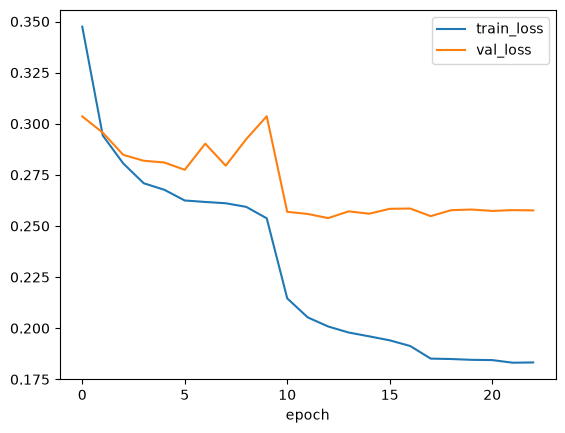

In [25]:
experiment_1_curves_df.plot(x='epoch', y=['train_loss', 'val_loss'])

# Experiment 2

In [26]:
EARLY_STOPPER_KWARGS={'patience':15}

In [27]:
experiment_2 = ModifiedFasterRCNN(
    detection_model=DETECTION_MODEL,
    optimizer=OPTIMIZER,
    learning_scheduler=SCHEDULER,
    early_stopper_class=EARLY_STOPPER,
    early_stopper_kwargs=EARLY_STOPPER_KWARGS)

In [29]:
experiment_2.replace_box_predictor(num_classes=NUM_CLASSES)

In [30]:
experiment_2.model.load_state_dict(torch.load('basketball_current.pt'))

<All keys matched successfully>

In [31]:
experiment_2.training_loop(
    train_loader, val_loader, device,
    epochs=60,                      # generous ceiling
    early_stopping='reset',         # fresh run, included for semantic clarity even though it is not needed as we instantiated a new experiment
    calculate_map_interval=5,       # populate _best_map_snapshot
    checkpoint_path='basketball_run2.pt',   # <- crash protection + best-loss saves
    save_period=10,                 # <- every-10-epoch safety nets
    
)

Starting detection training for 60 epoch(s)
  trainable params: 41,097,261 | train batches/epoch: 2400 | device: cuda

Epoch 1/60
  Epoch 1/60 batch 20/2400 | loss 0.1943 | loss_classifier=0.057 loss_box_reg=0.148 loss_objectness=0.015 loss_rpn_box_reg=0.017
  Epoch 1/60 batch 40/2400 | loss 0.1835 | loss_classifier=0.085 loss_box_reg=0.155 loss_objectness=0.002 loss_rpn_box_reg=0.010
  Epoch 1/60 batch 60/2400 | loss 0.1983 | loss_classifier=0.050 loss_box_reg=0.137 loss_objectness=0.007 loss_rpn_box_reg=0.011
  Epoch 1/60 batch 80/2400 | loss 0.1894 | loss_classifier=0.071 loss_box_reg=0.151 loss_objectness=0.006 loss_rpn_box_reg=0.017
  Epoch 1/60 batch 100/2400 | loss 0.1899 | loss_classifier=0.056 loss_box_reg=0.075 loss_objectness=0.001 loss_rpn_box_reg=0.004
  Epoch 1/60 batch 120/2400 | loss 0.1895 | loss_classifier=0.040 loss_box_reg=0.108 loss_objectness=0.001 loss_rpn_box_reg=0.009
  Epoch 1/60 batch 140/2400 | loss 0.1880 | loss_classifier=0.059 loss_box_reg=0.107 loss_obje

In [33]:
experiment_2.select_best_by_map(val_loader, device)

Selected checkpoint from epoch 4 (mAP=0.5932)


In [34]:
torch.save(experiment_2.model.state_dict(), 'basketball_run2.pt')

# Evaluation on test data

In [37]:
results = experiment_2.evaluate_detections(val_loader, device, return_full=True)
print("mAP@[.5:.95]:", results['map'].item() if hasattr(results['map'],'item') else results['map'])
print("mAP@50:", results['map_50'])
print("mAP@75:", results['map_75'])

mAP@[.5:.95]: 0.5932338833808899
mAP@50: 0.8981716632843018
mAP@75: 0.6620716452598572


In [35]:
results = experiment_2.evaluate_detections(test_loader, device, return_full=True,)
print("mAP@[.5:.95]:", results['map'].item() if hasattr(results['map'],'item') else results['map'])
print("mAP@50:", results['map_50'])
print("mAP@75:", results['map_75'])

mAP@[.5:.95]: 0.6048449277877808
mAP@50: 0.9037439227104187
mAP@75: 0.6801009178161621


In [39]:
metric = MeanAveragePrecision(box_format='xyxy', class_metrics=True)
experiment_2.set_model_mode('eval')
with torch.no_grad():
    for images, targets in test_loader:
        images = [img.to(device) for img in images]
        preds = experiment_2.model(images)
        preds_cpu = [{'boxes': p['boxes'].cpu(), 'scores': p['scores'].cpu(),
                      'labels': p['labels'].cpu()} for p in preds]
        targets_cpu = [{'boxes': torch.as_tensor(t['boxes']).cpu(),
                        'labels': t['labels'].cpu()} for t in targets]
        metric.update(preds_cpu, targets_cpu)
result = metric.compute()
print("mAP:", result['map'].item())
print("mAP@50:", result['map_50'].item())
print("per-class AP:", result['map_per_class'])
print("classes:", result['classes'])

mAP: 0.6048449277877808
mAP@50: 0.9037439227104187
per-class AP: tensor([0.5684, 0.6510, 0.5859, 0.6944, 0.5245])
classes: tensor([1, 2, 3, 4, 5], dtype=torch.int32)


In [52]:
result.keys()

dict_keys(['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 'map_per_class', 'mar_100_per_class', 'classes'])

In [54]:
pd.DataFrame({'class': [IDX_TO_CLASS[x] for x in result['classes'].numpy()], 'mAP': result['map_per_class']})

,class,mAP
0,ball,0.568373
1,ball_in_basket,0.650981
2,player,0.585928
3,basket,0.694422
4,player_shooting,0.524520


In [57]:
CLASS_NAMES = {1:'ball', 2:'ball_in_basket', 3:'player', 4:'basket', 5:'player_shooting'}

def per_class_map50(model, loader, device, class_ids=(1,2,3,4,5)):
    # collect all predictions and targets once (so we don't re-run the model per class)
    all_preds, all_targets = [], []
    model.set_model_mode('eval')
    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            preds = model.model(images)
            for p in preds:
                all_preds.append({'boxes': p['boxes'].cpu(),
                                  'scores': p['scores'].cpu(),
                                  'labels': p['labels'].cpu()})
            for t in targets:
                all_targets.append({'boxes': torch.as_tensor(t['boxes']).cpu(),
                                    'labels': t['labels'].cpu()})

    # for each class, run the metric restricted to that class -> its map_50
    out = {}
    for cid in class_ids:
        m = MeanAveragePrecision(box_format='xyxy')
        for p, t in zip(all_preds, all_targets):
            pmask = p['labels'] == cid
            tmask = t['labels'] == cid
            m.update(
                [{'boxes': p['boxes'][pmask], 'scores': p['scores'][pmask],
                  'labels': p['labels'][pmask]}],
                [{'boxes': t['boxes'][tmask], 'labels': t['labels'][tmask]}],
            )
        out[cid] = m.compute()['map_50'].item()
    return out

results = per_class_map50(experiment_2, test_loader, device)
for cid, v in results.items():
    print(f"{CLASS_NAMES[cid]:16s} mAP@50 = {v:.4f}")

ball             mAP@50 = 0.8581
ball_in_basket   mAP@50 = 0.8816
player           mAP@50 = 0.9230
basket           mAP@50 = 0.9582
player_shooting  mAP@50 = 0.8979
